# AI-Powered Student Risk & Employability Predictor

## GROUP 2

## Authors:
1. Andrew Nyakiba

2. Angela Wachira

3. Bobbin Bodo

4. Mercy Chepkoech

5. Ted Mwenda

### Instructor name: MARYANNE MWIKALI


### Project Type: Predictive Analytics - Supervised Machine Learning (Multiclass Classification)

### Datasets Used:


| Dataset | Source | Purpose |
|---|---|---|
| `data.csv` | UCI / Kaggle | Dropout prediction (primary, labelled) |
| `Academic_Risk_Prediction_DW.csv` | Kaggle | Supplementary academic features |
| `UECD_1200_dataset.csv` | Kaggle | Employability prediction |
| `Resume.csv` | Kaggle | NLP resume recommendations |

This notebook develops an AI-powered student success platform using academic and employability datasets. It utilizes machine learning classification to identify at-risk students and assess professional readiness to facilitate early institutional intervention and personalized career guidance.


## 1. Project Overview

Higher education plays a critical role in socio-economic mobility and personal development, making student success and workforce readiness essential priorities for educational institutions. This project focuses on predicting two key student outcomes: academic risk (dropout versus graduation) and employability readiness, using demographic, academic performance, and behavioral data collected from diverse student populations.

Through the application of advanced machine learning models, the study will identify the major factors influencing students’ educational trajectories and will estimate their likelihood of academic and career success. The insights that will be generated from this system can support institutions in implementing early intervention strategies for at-risk students and improving academic programs to better align with the evolving demands of the global workforce.

## 2. Business Understanding

### 2.1 Stakeholders

- University Administration: Focus on institutional retention and reputation.

- Academic Advisors: Utilize insights for early-warning student support.

- Students: Primary users for self-assessment and career planning.

- Career Services: To align student skills with industry demands.

- Employers: Interested in identifying job-ready candidates.


### 2.2 Business Problem

Institutions face high dropout rates and a significant gap between academic graduation and job market readiness. This project aims to predict academic failure and employability levels early to enable proactive institutional intervention and career guidance.

### 2.3 Objectives

- To build a classification model to predict student academic outcomes (Graduate, Dropout, Enrolled).

- To develop an employability assessment to categorize students into professional readiness levels.

- To identify the key demographic and academic features that drive student risk.

- To create a user-friendly interface for real-time prediction and decision-making.

### 2.4 Key Questions

1. What are the most significant predictors of student dropout?

2. How strongly do first-semester academic grades correlate with final graduation?

3. What impact do financial factors (scholarships and debt) have on student success?

4. Can we accurately predict a student's employability level based on their academic and technical skill profile?

### 3. Importation of Libraries

In [ ]:
# Install any missing packages (run once)
# !pip install xgboost shap wordcloud imbalanced-learn textblob

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Core data
import csv
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# NLP
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ML — preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# ML — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# ML — evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, classification_report)

# Clustering (NLP)
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# Explainability
import shap

# Persistence
import joblib
import os

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
#Global configuration
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})
PALETTE = ['#378ADD', '#D85A30', '#1D9E75', '#EF9F27', '#7F77DD', '#D4537E']

# File paths
PATH_DROPOUT   = 'data.csv'
PATH_ACADEMIC  = 'Academic Risk Prediction DW.csv'
PATH_EMPLOY    = 'UECD_1200_dataset.csv'
PATH_RESUME    = 'Resume.csv'

# Output directories
os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

print("✓ Configuration set — random seed:", RANDOM_SEED)

✓ Configuration set — random seed: 42


## Global Configuration

---



Sets a fixed random seed (42) to ensure reproducible results across all models and splits.
Plot styling defaults (figure size, spine removal, colour palette) are defined once here and
inherited by all charts in the notebook. Dataset file paths are declared as named constants
so any file changes require edits in one place only. Finally, the `models/` and `outputs/`
directories are created upfront so all export cells run without errors on any machine.

In [ ]:
# Download NLTK data (run once)
for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(pkg, quiet=True)
print("✓ NLTK resources ready")


✓ NLTK resources ready


## DATA LOADING

---



We load each dataset separately and inspect its shape, types, and quality before any transformation.

> **Note:** `data.csv` uses semicolons as delimiters and `Resume.csv` has BOM + nested-CSV encoding — both require special handling documented below.


In [ ]:
# Dropout dataset (data.csv)
# Semicolon-delimited; must pass sep=';'
df_dropout = pd.read_csv(PATH_DROPOUT, sep=';')

print(f"Shape : {df_dropout.shape}")
print(f"Target: {df_dropout['Target'].value_counts().to_dict()}")
df_dropout.head(3)


Shape : (4424, 37)
Target: {'Graduate': 2209, 'Dropout': 1421, 'Enrolled': 794}


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [ ]:
# Academic risk warehouse
df_academic = pd.read_csv(PATH_ACADEMIC)

print(f"Shape  : {df_academic.shape}")
print(f"Sources: {df_academic['source'].value_counts().to_dict()}")
df_academic.head(3)


Shape  : (11523, 40)
Sources: {'StudentFactors': 6607, 'StudentPerf': 2392, 'StudentGrades': 1044, 'PerfScores': 1000, 'xAPI': 480}


,fact_id,source,gender,age,grade_letter,raisedhands,visited_resources,announcements_view,discussion,absence_days,...,exam_score,attendance,hours_studied,motivation_level,internet_access,tutoring_sessions,parental_involvement,family_income,previous_scores,sleep_hours
0,1,xAPI,male,11,D,15,16,2,20,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
1,2,xAPI,male,12,C,20,20,3,25,under-7,...,67,80,20,medium,yes,1,medium,medium,67,7
2,3,xAPI,male,11,D,10,7,0,30,above-7,...,67,80,20,medium,yes,1,medium,medium,67,7


In [ ]:
# Employability dataset
df_employ = pd.read_csv(PATH_EMPLOY)

print(f"Shape: {df_employ.shape}")
print(f"Score present: {df_employ['Employment_Competitiveness_Score'].notna().sum()} / {len(df_employ)} rows")
df_employ.head(3)


Shape: (1200, 26)
Score present: 620 / 1200 rows


,GPA,Core_Subject_Score,Academic_Consistency,Research_Participation,Programming_Skill,Domain_Knowledge,Tool_Proficiency,Certification_Count,Internship_Count,Internship_Duration,...,Learning_Motivation,Career_Clarity,Market_Awareness,Higher_Study_Interest,Target_Industry_Code,Workshop_Participation,Online_Course_Hours,Networking_Activity,Learning_Path_Generation_Time,Employment_Competitiveness_Score
0,7.19,66.0,2.14,1.0,48.0,51.0,35.0,2.0,3.0,13.0,...,50.0,89.0,93.0,0.0,NaN,6.0,243.4,23.0,8.98,30.55
1,9.78,61.0,1.42,0.0,70.0,85.0,75.0,5.0,0.0,7.3,...,97.0,35.0,91.0,1.0,5.0,11.0,20.0,44.0,8.98,NaN
2,8.79,83.0,1.22,0.0,54.0,52.0,79.0,5.0,3.0,3.9,...,77.0,36.0,88.0,1.0,3.0,5.0,96.5,55.0,6.21,66.03


In [ ]:
# Resume dataset (BOM + nested-CSV encoding)
def load_resume_csv(path):
    """Parse Resume.csv which wraps each row as a single quoted CSV cell."""
    rows = []
    with open(path, 'r', encoding='utf-8-sig') as f:
        for row in csv.reader(f):
            if row:
                rows.append(list(csv.reader([row[0]]))[0])
    header, data = rows[0], rows[1:]
    return pd.DataFrame(data, columns=header)

df_resume = load_resume_csv(PATH_RESUME)

print(f"Shape     : {df_resume.shape}")
print(f"Categories: {df_resume['category'].nunique()} unique")
df_resume.head(3)


Shape     : (2856, 5)
Categories: 65 unique


,resume_id,category,resume_text,skills_list,experience_years
0,1,HR,hr administrator marketing associate hr admini...,hr administrator marketing associate hr admini...,0.0
1,2,HR,hr specialist us hr operations summary versati...,hr specialist us hr operations summary versati...,0.0
2,3,HR,hr director summary over years experience in r...,hr director summary over years experience in r...,20.0


In [ ]:
# Dataset summary stats
for name, df in [('Dropout', df_dropout), ('Academic', df_academic),
                 ('Employability', df_employ), ('Resume', df_resume)]:
    nulls = df.isnull().sum().sum()
    dups  = df.duplicated().sum()
    print(f"{name:15s} | rows={len(df):,}  cols={df.shape[1]}  nulls={nulls}  dups={dups}")


Dropout         | rows=4,424  cols=37  nulls=0  dups=0
Academic        | rows=11,523  cols=40  nulls=0  dups=0
Employability   | rows=1,200  cols=26  nulls=1480  dups=0
Resume          | rows=2,856  cols=5  nulls=80  dups=0


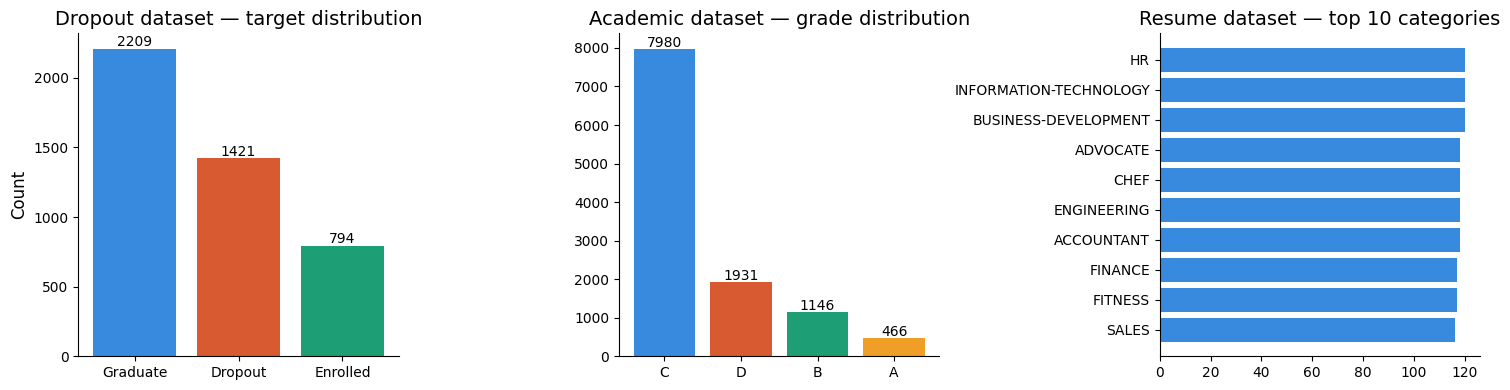

Chart saved → outputs/01_class_distributions.png


In [ ]:
# Class distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dropout target
counts = df_dropout['Target'].value_counts()
axes[0].bar(counts.index, counts.values, color=PALETTE[:3])
axes[0].set_title('Dropout dataset — target distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Academic grade letters
counts2 = df_academic['grade_letter'].value_counts()
axes[1].bar(counts2.index, counts2.values, color=PALETTE[:4])
axes[1].set_title('Academic dataset — grade distribution')
for i, v in enumerate(counts2.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=10)

# Resume categories (top 10)
counts3 = df_resume['category'].value_counts().head(10)
axes[2].barh(counts3.index, counts3.values, color=PALETTE[0])
axes[2].set_title('Resume dataset — top 10 categories')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/01_class_distributions.png', bbox_inches='tight')
plt.show()
print("Chart saved → outputs/01_class_distributions.png")


## Class Distribution Plots

---



Visualises the target variable distributions across three datasets loaded in this section.
The dropout dataset shows the three outcome classes (Graduate, Dropout, Enrolled). The
academic dataset shows the grade letter spread across all students. The resume dataset
shows the top 10 job categories by frequency. These plots give an early indication of
class imbalance before any preprocessing is applied.





## Data Exploration & Cleaning


---



Before visualising any distributions, we inspect each dataset for structural issues and
apply targeted fixes. This section covers:

- Data types and shape verification
- Duplicate row detection and removal
- Null value identification and treatment strategy per dataset
- Column name anomalies
- Outlier and inconsistency checks
- A clean summary confirming each dataset is ready for EDA

No feature engineering or scaling is done here — that is reserved for Section 04 (Preprocessing).


### Shape & Data Type Audit

In [ ]:
# Quick audit of shape and dtype composition for all four datasets
audit_rows = []
for name, df in [('Dropout', df_dropout), ('Academic', df_academic),
                 ('Employability', df_employ), ('Resume', df_resume)]:
    dtypes = df.dtypes.value_counts().to_dict()
    audit_rows.append({
        'Dataset':    name,
        'Rows':       df.shape[0],
        'Columns':    df.shape[1],
        'Numeric cols':   sum(v for k, v in dtypes.items() if 'int' in str(k) or 'float' in str(k)),
        'Object cols':    dtypes.get(object, 0),
        'Total nulls':    df.isnull().sum().sum(),
        'Duplicate rows': df.duplicated().sum(),
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)


,Dataset,Rows,Columns,Numeric cols,Object cols,Total nulls,Duplicate rows
0,Dropout,4424,37,36,0,0,0
1,Academic,11523,40,28,0,0,0
2,Employability,1200,26,26,0,1480,0
3,Resume,2856,5,0,0,80,0


### 2.2 — Dropout Dataset (`data.csv`)

**Issues found:**
- One column name contains a trailing tab character: `'Daytime/evening attendance\t'` — causes silent key errors downstream
- All other columns are correctly typed (29 int, 7 float, 1 object target)
- Zero nulls, zero duplicates — no imputation needed


In [ ]:
# Inspect column names for anomalies
print("Columns with special characters:")
for col in df_dropout.columns:
    if not col.replace(' ','').replace('(','').replace(')','').replace('/','').replace("'","").replace(',','').isalnum():
        print(f"  repr: {repr(col)}")
